<a href="https://colab.research.google.com/github/NataCode13/Challenge-2-ETL/blob/main/TelecomX_LATAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###Introducción

El objetivo de este análisis fue identificar patrones asociados a la evasión de clientes en Telecom X.
Para ello, se extrajeron los datos desde un archivo JSON, se transformaron a un DataFrame, se limpiaron y prepararon para entender qué perfiles de clientes presentan mayor probabilidad de cancelar el servicio.

#📌 Extracción

In [1]:
import json
import requests
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pandas import json_normalize

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')

with open('/content/TelecomX_Data.json', 'r', encoding='utf-8') as f:
    data = json.load(f)

# Aplanar el JSON anidado
df = json_normalize(data, sep='.')

# Renombrar columnas para facilitar el análisis
df = df.rename(columns={
    'customer.gender': 'gender',
    'customer.SeniorCitizen': 'SeniorCitizen',
    'customer.Partner': 'Partner',
    'customer.Dependents': 'Dependents',
    'customer.tenure': 'tenure',
    'phone.PhoneService': 'PhoneService',
    'phone.MultipleLines': 'MultipleLines',
    'internet.InternetService': 'InternetService',
    'internet.OnlineSecurity': 'OnlineSecurity',
    'internet.OnlineBackup': 'OnlineBackup',
    'internet.DeviceProtection': 'DeviceProtection',
    'internet.TechSupport': 'TechSupport',
    'internet.StreamingTV': 'StreamingTV',
    'internet.StreamingMovies': 'StreamingMovies',
    'account.Contract': 'Contract',
    'account.PaperlessBilling': 'PaperlessBilling',
    'account.PaymentMethod': 'PaymentMethod',
    'account.Charges.Monthly': 'Charges.Monthly',
    'account.Charges.Total': 'Charges.Total'
})

print('Dimensión inicial:', df.shape)
display(df.head())
df.info()


Dimensión inicial: (7267, 21)


,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


#🔧 Transformación

In [2]:
df_clean = df.copy()
#se corrigen valores faltantes y formatos numéricos
for col in df_clean.columns:
    if df_clean[col].dtype == 'object':
        df_clean[col] = df_clean[col].astype(str).str.strip()

df_clean = df_clean.replace({'': np.nan})

df_clean['tenure'] = pd.to_numeric(df_clean['tenure'], errors='coerce')
df_clean['Charges.Monthly'] = pd.to_numeric(df_clean['Charges.Monthly'], errors='coerce')
df_clean['Charges.Total'] = pd.to_numeric(df_clean['Charges.Total'], errors='coerce')

print('Valores nulos antes del tratamiento:')
display(df_clean.isna().sum().sort_values(ascending=False))

df_clean.loc[
    (df_clean['tenure'] == 0) & (df_clean['Charges.Total'].isna()),
    'Charges.Total'] = 0

#Se eliminan registros sin información en 'Churn'
df_clean = df_clean.dropna(subset=['Churn']).copy()

df_clean['MultipleLines'] = df_clean['MultipleLines'].replace({'No phone service': 'No'})

cols_internet = [
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies']

for col in cols_internet:
    df_clean[col] = df_clean[col].replace({'No internet service': 'No'})

#se crea la variable 'Cuentas_Diarias'
df_clean['Cuentas_Diarias'] = df_clean['Charges.Monthly'] / 30

#se transforman los casos con valores textuales
bin_map = {'Yes': 1, 'No': 0}
binary_cols = ['Churn', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']

for col in binary_cols:
    df_clean[col + '_bin'] = df_clean[col].map(bin_map)

df_clean['gender_bin'] = df_clean['gender'].map({'Female': 0, 'Male': 1})
df_clean['SeniorCitizen_bin'] = df_clean['SeniorCitizen'].astype(int)

print('Dimensión final después de limpieza:', df_clean.shape)
print('\nValores nulos después del tratamiento:')
display(df_clean.isna().sum().sort_values(ascending=False))
display(df_clean.head())


Valores nulos antes del tratamiento:


,0
Churn,224
Charges.Total,11
customerID,0
SeniorCitizen,0
gender,0
Partner,0
Dependents,0
PhoneService,0
tenure,0
InternetService,0


Dimensión final después de limpieza: (7043, 29)

Valores nulos después del tratamiento:


,0
customerID,0
Churn,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0


,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Cuentas_Diarias,Churn_bin,Partner_bin,Dependents_bin,PhoneService_bin,PaperlessBilling_bin,gender_bin,SeniorCitizen_bin
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.186667,0,1,1,1,1,0,0
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,1.996667,0,0,0,1,0,1,0
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.463333,1,0,0,1,1,1,0
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.266667,1,1,0,1,1,1,1
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.796667,1,1,0,1,1,0,1


#📊 Carga y análisis

Estadísticas descriptivas de variables numéricas:


,count,mean,std,min,25%,50%,75%,max
tenure,7043.0,32.371149,24.559481,0.000000,9.000000,29.000,55.000,72.000000
Charges.Monthly,7043.0,64.761692,30.090047,18.250000,35.500000,70.350,89.850,118.750000
Charges.Total,7043.0,2279.734304,2266.794470,0.000000,398.550000,1394.550,3786.600,8684.800000
Cuentas_Diarias,7043.0,2.158723,1.003002,0.608333,1.183333,2.345,2.995,3.958333



Medianas:


,mediana
tenure,29.000
Charges.Monthly,70.350
Charges.Total,1394.550
Cuentas_Diarias,2.345


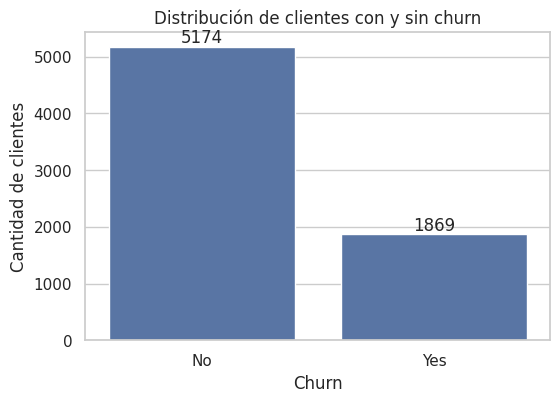

Proporción de churn:


,%
Churn,
No,73.46
Yes,26.54



Distribución porcentual de churn por gender:


Churn,% No churn,% Churn
gender,,
Female,73.08,26.92
Male,73.84,26.16


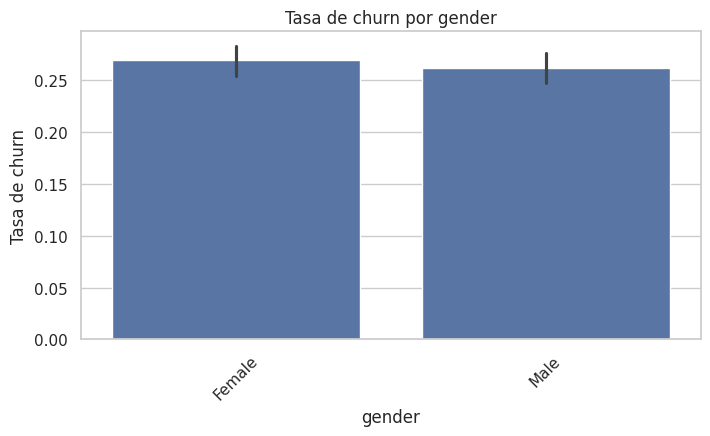


Distribución porcentual de churn por SeniorCitizen:


Churn,% No churn,% Churn
SeniorCitizen,,
1,58.32,41.68
0,76.39,23.61


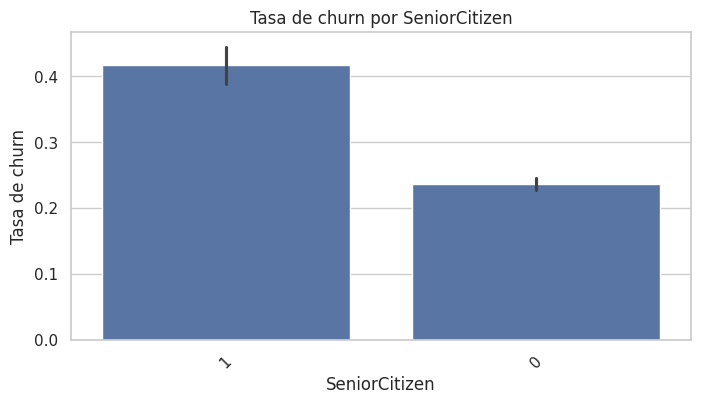


Distribución porcentual de churn por Contract:


Churn,% No churn,% Churn
Contract,,
Month-to-month,57.29,42.71
One year,88.73,11.27
Two year,97.17,2.83


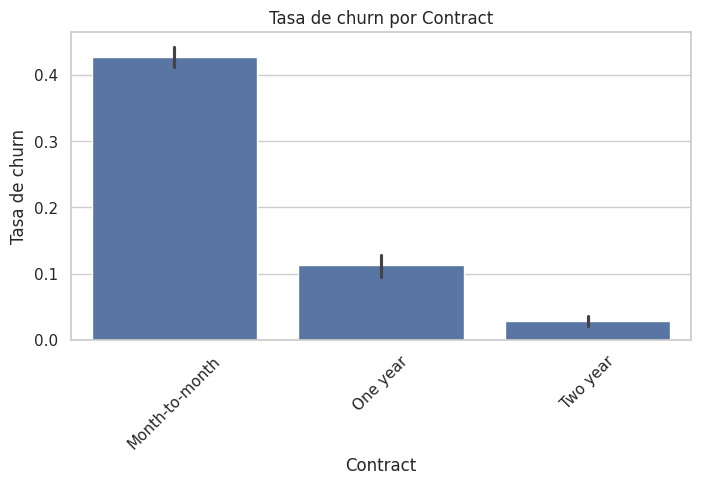


Distribución porcentual de churn por PaymentMethod:


Churn,% No churn,% Churn
PaymentMethod,,
Electronic check,54.71,45.29
Mailed check,80.89,19.11
Bank transfer (automatic),83.29,16.71
Credit card (automatic),84.76,15.24


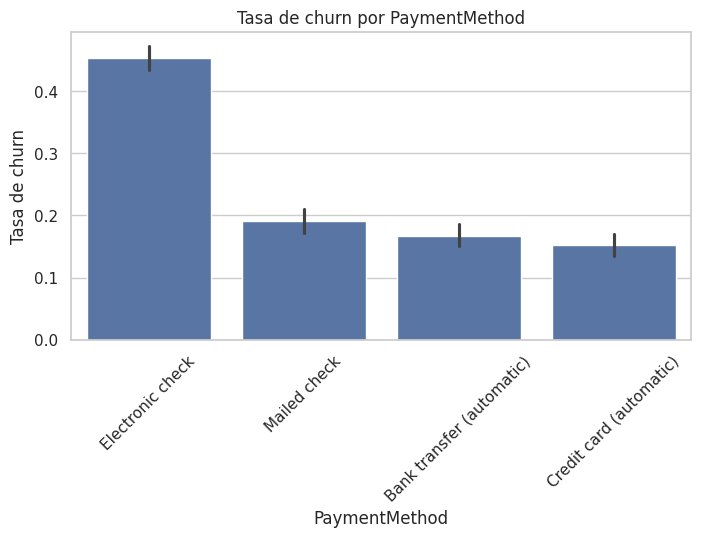


Distribución porcentual de churn por InternetService:


Churn,% No churn,% Churn
InternetService,,
Fiber optic,58.11,41.89
DSL,81.04,18.96
No,92.60,7.40


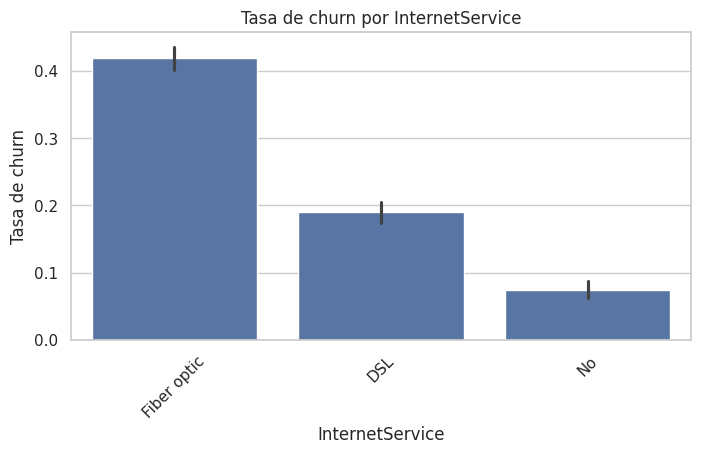


Distribución porcentual de churn por PaperlessBilling:


Churn,% No churn,% Churn
PaperlessBilling,,
Yes,66.43,33.57
No,83.67,16.33


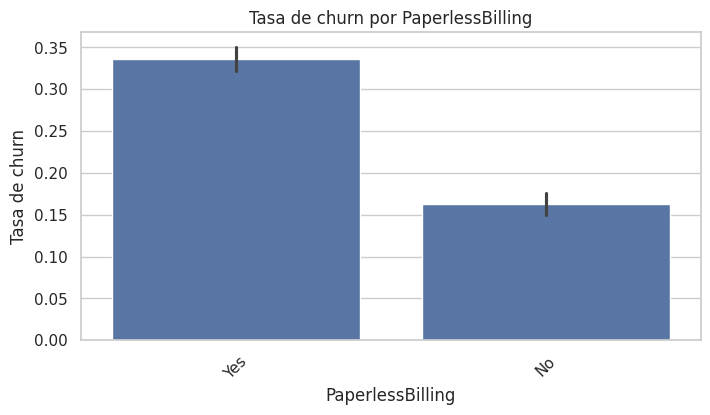


Distribución porcentual de churn por Partner:


Churn,% No churn,% Churn
Partner,,
No,67.04,32.96
Yes,80.34,19.66


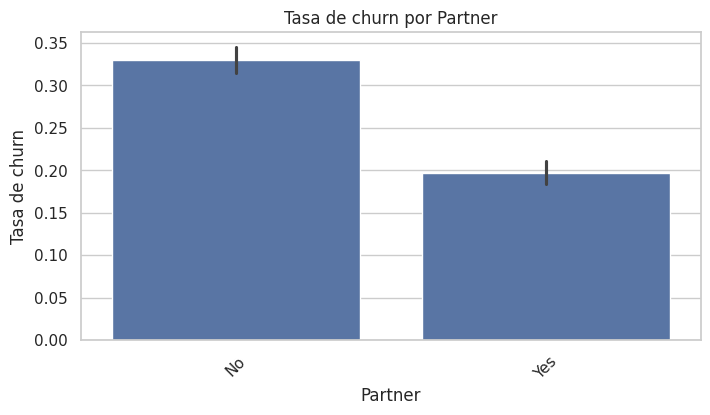


Distribución porcentual de churn por Dependents:


Churn,% No churn,% Churn
Dependents,,
No,68.72,31.28
Yes,84.55,15.45


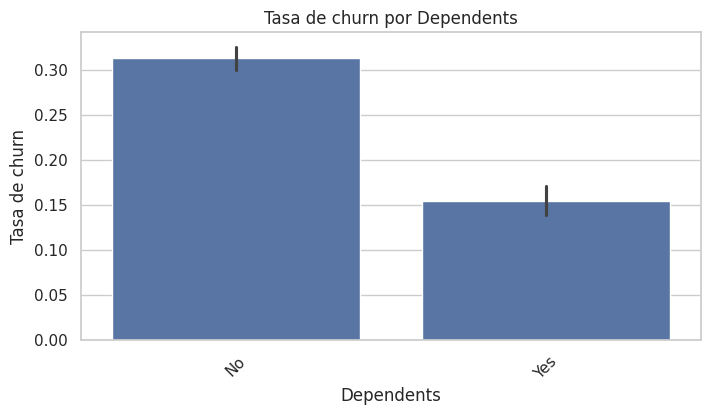


Distribución porcentual de churn por TechSupport:


Churn,% No churn,% Churn
TechSupport,,
No,68.81,31.19
Yes,84.83,15.17


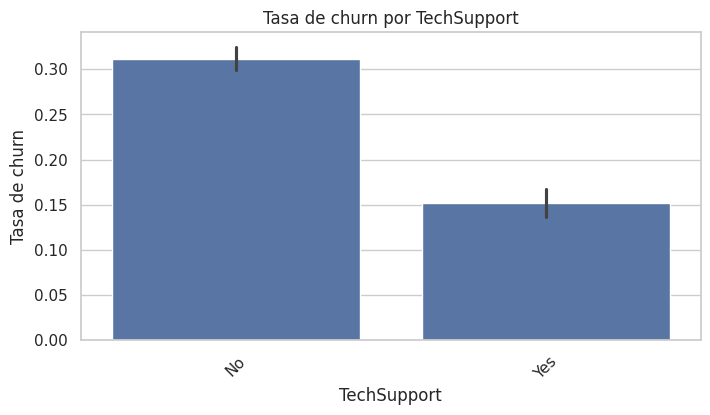


Distribución porcentual de churn por OnlineSecurity:


Churn,% No churn,% Churn
OnlineSecurity,,
No,68.67,31.33
Yes,85.39,14.61


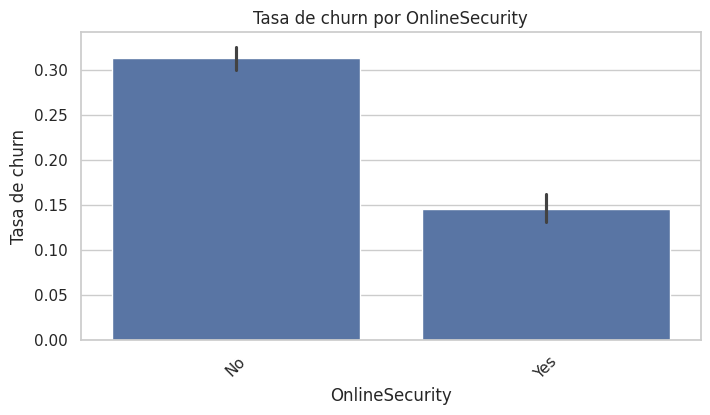

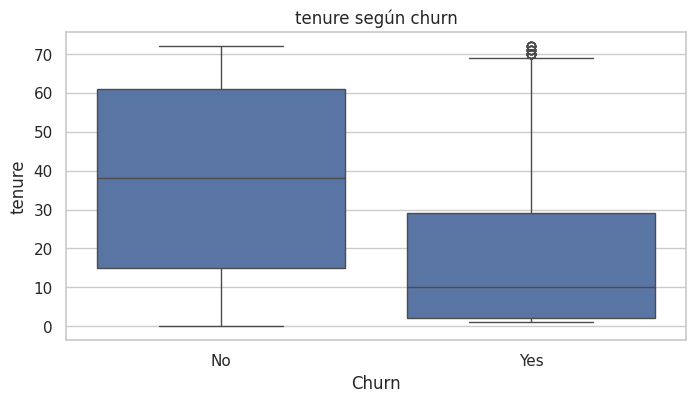

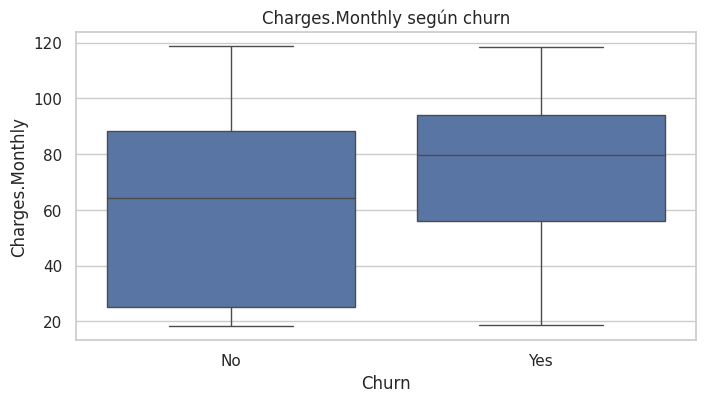

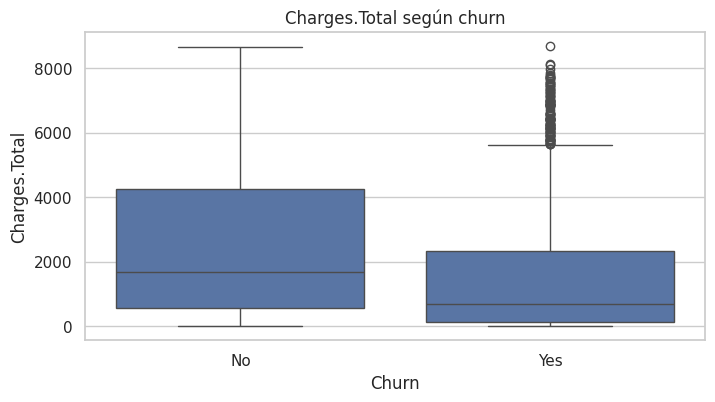

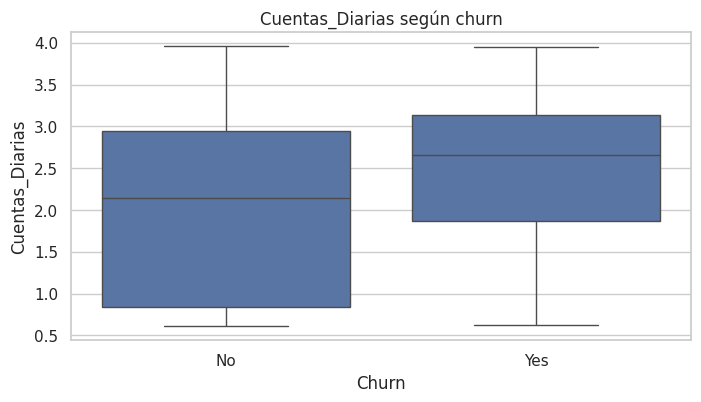

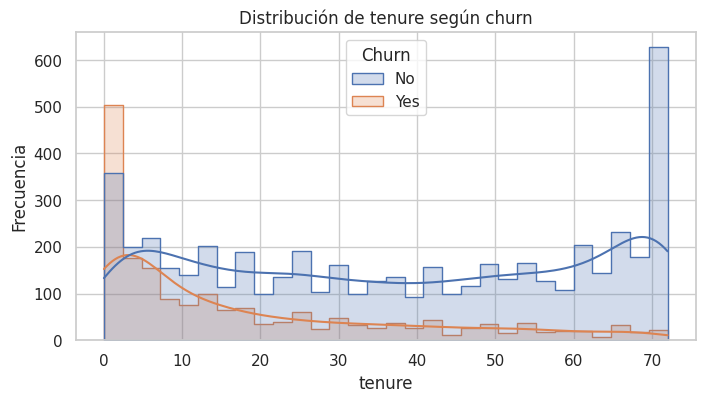

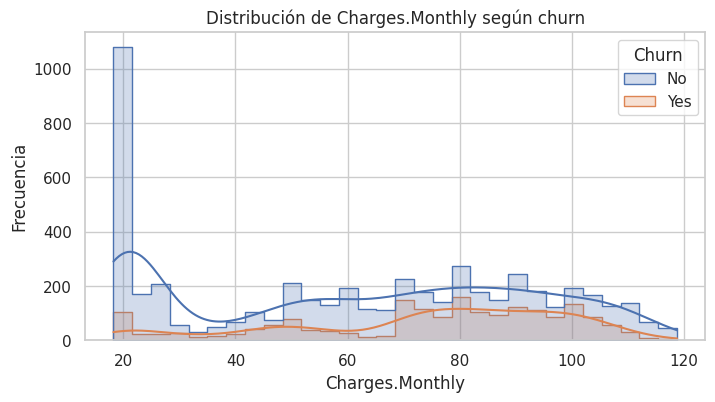

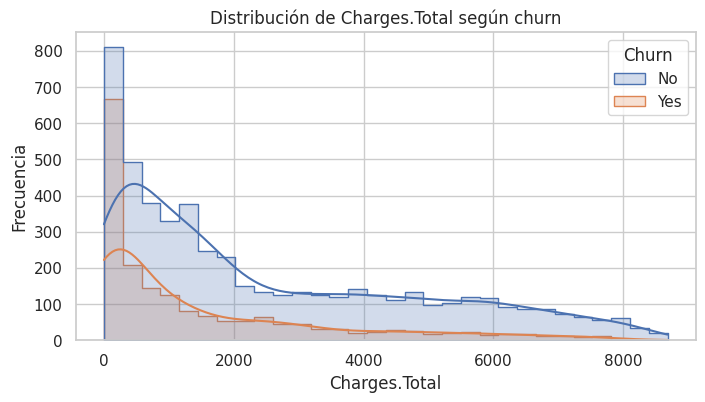

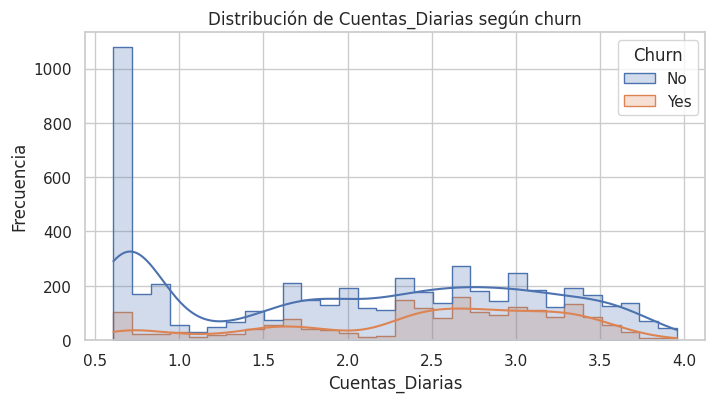


Resumen numérico por churn:


tenure               Charges.Monthly               Charges.Total  \
        mean median    std            mean median    std          mean   
Churn                                                                    
No     37.57   38.0  24.11           61.27  64.43  31.09       2549.91   
Yes    17.98   10.0  19.53           74.44  79.65  24.67       1531.80   

                        Cuentas_Diarias               
        median      std            mean median   std  
Churn                                                 
No     1679.52  2329.95            2.04   2.15  1.04  
Yes     703.55  1890.82            2.48   2.66  0.82


Tasa de churn por antigüedad:


Churn,No,Yes
tenure_grupo,,
0-6,47.06,52.94
7-12,64.11,35.89
13-24,71.29,28.71
25-48,79.61,20.39
49-72,90.49,9.51



Tasa de churn por cargo mensual:


Churn,No,Yes
cargo_grupo,,
0-30,90.20,9.80
31-60,74.07,25.93
61-90,66.09,33.91
91-120,67.22,32.78



Combinaciones con mayor riesgo de churn:


,Contract,PaymentMethod,InternetService,tasa_churn,clientes
7,Month-to-month,Electronic check,Fiber optic,60.37,1307
10,Month-to-month,Mailed check,Fiber optic,50.75,201
1,Month-to-month,Bank transfer (automatic),Fiber optic,45.57,327
4,Month-to-month,Credit card (automatic),Fiber optic,41.64,293
6,Month-to-month,Electronic check,DSL,40.51,474
9,Month-to-month,Mailed check,DSL,30.79,367
3,Month-to-month,Credit card (automatic),DSL,27.03,185
19,One year,Electronic check,Fiber optic,26.02,196
11,Month-to-month,Mailed check,No,20.62,325
2,Month-to-month,Bank transfer (automatic),No,20.00,65


In [3]:
print('Estadísticas descriptivas de variables numéricas:')
display(df_clean[['tenure', 'Charges.Monthly', 'Charges.Total', 'Cuentas_Diarias']].describe().T)

print('\nMedianas:')
display(df_clean[['tenure', 'Charges.Monthly', 'Charges.Total', 'Cuentas_Diarias']].median().to_frame('mediana'))

plt.figure(figsize=(6,4))
ax = sns.countplot(data=df_clean, x='Churn')
plt.title('Distribución de clientes con y sin churn')
plt.xlabel('Churn')
plt.ylabel('Cantidad de clientes')
for container in ax.containers:
    ax.bar_label(container)
plt.show()

print('Proporción de churn:')
display((df_clean['Churn'].value_counts(normalize=True) * 100).round(2).to_frame('%'))

cat_cols = ['gender', 'SeniorCitizen', 'Contract', 'PaymentMethod', 'InternetService',
            'PaperlessBilling', 'Partner', 'Dependents', 'TechSupport', 'OnlineSecurity']

for col in cat_cols:
    tabla = pd.crosstab(df_clean[col], df_clean['Churn'], normalize='index') * 100
    tabla = tabla.rename(columns={'No': '% No churn', 'Yes': '% Churn'}).round(2)
    print(f'\nDistribución porcentual de churn por {col}:')
    display(tabla.sort_values('% Churn', ascending=False))

    plt.figure(figsize=(8,4))
    orden = df_clean.groupby(col)['Churn_bin'].mean().sort_values(ascending=False).index
    sns.barplot(data=df_clean, x=col, y='Churn_bin', order=orden)
    plt.title(f'Tasa de churn por {col}')
    plt.xlabel(col)
    plt.ylabel('Tasa de churn')
    plt.xticks(rotation=45)
    plt.show()

num_cols = ['tenure', 'Charges.Monthly', 'Charges.Total', 'Cuentas_Diarias']

for col in num_cols:
    plt.figure(figsize=(8,4))
    sns.boxplot(data=df_clean, x='Churn', y=col)
    plt.title(f'{col} según churn')
    plt.xlabel('Churn')
    plt.ylabel(col)
    plt.show()

for col in num_cols:
    plt.figure(figsize=(8,4))
    sns.histplot(data=df_clean, x=col, hue='Churn', kde=True, bins=30, element='step')
    plt.title(f'Distribución de {col} según churn')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
    plt.show()

resumen_churn = df_clean.groupby('Churn')[num_cols].agg(['mean', 'median', 'std']).round(2)
print('\nResumen numérico por churn:')
display(resumen_churn)

df_clean['tenure_grupo'] = pd.cut(
    df_clean['tenure'],
    bins=[-1, 6, 12, 24, 48, 72],
    labels=['0-6', '7-12', '13-24', '25-48', '49-72'])

df_clean['cargo_grupo'] = pd.cut(
    df_clean['Charges.Monthly'],
    bins=[0, 30, 60, 90, 120],
    labels=['0-30', '31-60', '61-90', '91-120'])

print('\nTasa de churn por antigüedad:')
display((pd.crosstab(df_clean['tenure_grupo'], df_clean['Churn'], normalize='index') * 100).round(2))

print('\nTasa de churn por cargo mensual:')
display((pd.crosstab(df_clean['cargo_grupo'], df_clean['Churn'], normalize='index') * 100).round(2))

top_riesgo = (
    df_clean.groupby(['Contract', 'PaymentMethod', 'InternetService'])['Churn_bin']
    .agg(['mean', 'count'])
    .reset_index()
    .rename(columns={'mean': 'tasa_churn', 'count': 'clientes'}))

top_riesgo['tasa_churn'] = (top_riesgo['tasa_churn'] * 100).round(2)
top_riesgo = top_riesgo.sort_values(['tasa_churn', 'clientes'], ascending=[False, False])

print('\nCombinaciones con mayor riesgo de churn:')
display(top_riesgo.head(10))


#📄Informe final

In [11]:
from IPython.display import Markdown, display

total_clientes = len(df_clean)
clientes_churn = int(df_clean['Churn_bin'].sum())
tasa_churn = round(df_clean['Churn_bin'].mean() * 100, 2)

prom_tenure_churn = round(df_clean.loc[df_clean['Churn'] == 'Yes', 'tenure'].mean(), 2)
prom_tenure_no = round(df_clean.loc[df_clean['Churn'] == 'No', 'tenure'].mean(), 2)

prom_mensual_churn = round(df_clean.loc[df_clean['Churn'] == 'Yes', 'Charges.Monthly'].mean(), 2)
prom_mensual_no = round(df_clean.loc[df_clean['Churn'] == 'No', 'Charges.Monthly'].mean(), 2)

medio_pago_riesgo = df_clean.groupby('PaymentMethod')['Churn_bin'].mean().sort_values(ascending=False).index[0]
internet_riesgo = df_clean.groupby('InternetService')['Churn_bin'].mean().sort_values(ascending=False).index[0]

informe = f"""
#Informe final: Análisis de evasión de clientes (Churn)

##Análisis exploratorio
La base final quedó con **{total_clientes} clientes**, de los cuales **{clientes_churn}** cancelaron el servicio.
La tasa general de evasión fue de **{tasa_churn}%**.

- La base final quedó con **{total_clientes} clientes**, de los cuales **{clientes_churn}** cancelaron el servicio.
- La tasa general de evasión fue de **{tasa_churn}%**.

##Principales patrones encontrados:
- Los clientes que cancelan tienen una antigüedad promedio menor (**{prom_tenure_churn} meses**) que quienes permanecen (**{prom_tenure_no} meses**).
- Los clientes con churn presentan un cargo mensual promedio más alto (**{prom_mensual_churn}**) que los que no cancelan (**{prom_mensual_no}**).
- El tipo de contrato más riesgoso es **Month-to-month**.
- El método de pago con mayor evasión es **{medio_pago_riesgo}**.
- El servicio de internet con mayor riesgo de baja es **{internet_riesgo}**.
- También se observa mayor evasión en clientes sin pareja, sin dependientes, con facturación electrónica y sin servicios de soporte o seguridad adicional.

##Conclusiones
Los resultados muestran que la evasión se concentra en clientes:
- con contratos mensuales,
- con poca antigüedad,
- con cargos mensuales relativamente altos,
- con internet de fibra óptica,
- que pagan mediante electronic check,
- y que no cuentan con servicios de valor agregado como soporte técnico o seguridad online.

##Recomendaciones
1. Diseñar campañas de retención para clientes con baja antigüedad (primeros 6 a 12 meses).
2. Incentivar actulización de contratos mensuales a contratos de uno o dos años mediante descuentos o beneficios.
3. Revisar la experiencia y precio del segmento de fibra óptica, ya que concentra una evasión elevada.

"""

display(Markdown(informe))



#Informe final: Análisis de evasión de clientes (Churn)

##Análisis exploratorio
La base final quedó con **7043 clientes**, de los cuales **1869** cancelaron el servicio.
La tasa general de evasión fue de **26.54%**.

- La base final quedó con **7043 clientes**, de los cuales **1869** cancelaron el servicio.
- La tasa general de evasión fue de **26.54%**.

##Principales patrones encontrados:
- Los clientes que cancelan tienen una antigüedad promedio menor (**17.98 meses**) que quienes permanecen (**37.57 meses**).
- Los clientes con churn presentan un cargo mensual promedio más alto (**74.44**) que los que no cancelan (**61.27**).
- El tipo de contrato más riesgoso es **Month-to-month**.
- El método de pago con mayor evasión es **Electronic check**.
- El servicio de internet con mayor riesgo de baja es **Fiber optic**.
- También se observa mayor evasión en clientes sin pareja, sin dependientes, con facturación electrónica y sin servicios de soporte o seguridad adicional.

##Conclusiones
Los resultados muestran que la evasión se concentra en clientes:
- con contratos mensuales,
- con poca antigüedad,
- con cargos mensuales relativamente altos,
- con internet de fibra óptica,
- que pagan mediante electronic check,
- y que no cuentan con servicios de valor agregado como soporte técnico o seguridad online.

##Recomendaciones
1. Diseñar campañas de retención para clientes con baja antigüedad (primeros 6 a 12 meses).
2. Incentivar actulización de contratos mensuales a contratos de uno o dos años mediante descuentos o beneficios.
3. Revisar la experiencia y precio del segmento de fibra óptica, ya que concentra una evasión elevada.

